In [49]:
#Install libraries ONLY RUN THIS IF YOU DO NOT HAVE IT
!pip install pandas numpy vaderSentiment textblob matplotlib seaborn bs4 contractions transformers torch huggingface_hub[hf_xet] hf_xet

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB 262.6 kB/s eta 0:00:11
    --------------------------------------- 0.1/2.9 MB 491.5 kB/s eta 0:00:06
   --- ------------------------------------ 0.3/2.9 MB 1.4 MB/s eta 0:00:02
   ------- -------------------------------- 0.6/2.9 MB 2.5 MB/s eta 0:00:01
   ----------- ---------------------------- 0.8/2.9 MB 3.2 MB/s eta 0:00:01
   ---------------- ----------------------- 1.2/2.9 MB 3.7 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.9 MB 4.5 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.9 MB 5.4 MB/s eta 0:00:01
   -------------------------------------- - 2.8/2.9 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 6.0 MB/s eta 0:00:00


In [2]:
#Necessary Libraries for this File
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
import statistics
import datetime
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from bs4 import BeautifulSoup
import contractions
import random
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from spacy.lang.en.stop_words import STOP_WORDS
import spacy
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

In [3]:
#STEP 1:
#Dataset Chosen: Airline Reviews
#URL for Dataset: https://www.kaggle.com/datasets/chaudharyanshul/airline-reviews
#Why this dataset: This is a real world problem that companies are dealing with all the time. It is important to be able to perform a text
# analysis on the reviews that they are receiving. In a customer service industry it is important to take every single piece of information to improve the customer
# service you are providing. Even if it is qualitative data, it is important to understand everything that people write about the company. This information
# being public can affect the company's bottom line and the way that other people percieve the airline (in this case, British Airways).

#Import the Dataset so that we can begin to explore it. Edit the path depending on the download
review_df=pd.read_csv(r"C:\Users\ysass\OneDrive\Desktop\Grad School Files\BSAN 6200 Text Mining and Social Media Analytics\text-analytics-spring-2026\assignment1\data\raw\BA_AirlineReviews.csv",header=0, index_col='Id', encoding="utf-8")

In [4]:
#STEP 2: Exploring the Dataset


review_df
#2.1.1 Metadata Description: Answer the Following Questions
#Columns and what the datatypes should be?
#Id- the ID of the row in the dataset(Should be a string because
#OverallRating- The overall rating given to the British Airways by the customer. (This should be an float because it can have decimal value)
#ReviewHeader- The header or title of the customer's review (String because it is a title with text)
#Name- Name of the customer that is giving the review to British Airways (Should be a string because it is a value)
#Datetime- The date the person wrote the review. (As it currently sits it is a string, but once we remove the th or rd from the string, it should be a datetime value)
#VerifiedReview-Indicates whether the review is verified or not (Boolean because it is either verified or not)
#ReviewBody- The full review written out by the customer (String because it is a full body of text)
#TypeOfTraveller- The type of traveller (i.e. Business, Leisure, etc.). (String because it is comprised of text)
#SeatType- Class of the traveler i.e. Economy, Business, etc. (String because it describes the class in text)
#Route-Flight Route taken by the customer (String because it is comprised of text)
#DateFlown- The date the person flew. (As it currently sits it is a string, but once we remove the th or rd from the string, it should be a datetime value)
#SeatComfort- Rating the comfort of the seat. (This should be an float because it can have decimal value)
#CabinStaffService- Rating of the flight attendants and cabin service staff. (This should be an float because it can have decimal value)
#GroundService- Rating for the ground service (i.e. Check-in, service desk, etc.). (This should be an float because it can have decimal value)
#ValueForMoney- Rating for the value of money. (This should be an float because it can have decimal value)
#Recommended- Whether the customer recommends British Airways. (It is a Boolean because they either recommend the airline or do not)
#Aircraft- The type of aircraft used for the flight. (String because it is something that we can't change and includes text)
#Food&Beverages- Rating for food and beverages. (This should be an float because it can have decimal value)
#InflightEntertainment- Rating for inflight entertainment. (This should be an float because it can have decimal value)
#Wifi&Connectivity- Rating for onboard wifi and connectivity. (This should be an float because it can have decimal value)


,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
Id,,,,,,,,,,,,,,,,,,,
0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,Nov-23,1.0,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN
1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,Nov-23,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0
2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,Nov-23,3.0,3.0,4.0,3.0,yes,A320,4.0,NaN,NaN
3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,Dec-22,3.0,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN
4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,Nov-23,1.0,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,1.0,British Airways customer review,J Robertson,29th August 2012,False,This was a bmi Regional operated flight on a R...,NaN,Economy Class,NaN,NaN,3.0,1.0,NaN,3.0,no,NaN,2.0,NaN,NaN
3697,9.0,British Airways customer review,Nick Berry,28th August 2012,False,LHR to HAM. Purser addresses all club passenge...,NaN,Business Class,NaN,NaN,4.0,5.0,NaN,3.0,yes,NaN,4.0,NaN,NaN
3698,5.0,British Airways customer review,Avril Barclay,12th October 2011,False,My son who had worked for British Airways urge...,NaN,Economy Class,NaN,NaN,NaN,NaN,NaN,4.0,yes,NaN,NaN,NaN,NaN


In [5]:
#2.1.2: What are the datatypes of the columns currently?
#Code identifies the data types for each column in the review_df
review_df.dtypes

OverallRating            float64
ReviewHeader              object
Name                      object
Datetime                  object
VerifiedReview              bool
ReviewBody                object
TypeOfTraveller           object
SeatType                  object
Route                     object
DateFlown                 object
SeatComfort              float64
CabinStaffService        float64
GroundService            float64
ValueForMoney            float64
Recommended               object
Aircraft                  object
Food&Beverages           float64
InflightEntertainment    float64
Wifi&Connectivity        float64
dtype: object

In [6]:
#2.1.3: How many rows are there?

#Code sets the number of rows (length) within the dataframe to a variable
num_rows=len(review_df)

#Print out the number of rows
print(f"There are {num_rows} rows in this dataset")

There are 3701 rows in this dataset


In [7]:
#2.1.4: Number of Missing Values per column

#Counts the number of NA values and sums it up to show how many missing values were in each column
review_df.isna().sum()

OverallRating               5
ReviewHeader                0
Name                        0
Datetime                    0
VerifiedReview              0
ReviewBody                  0
TypeOfTraveller           771
SeatType                    2
Route                     775
DateFlown                 778
SeatComfort               116
CabinStaffService         127
GroundService             846
ValueForMoney               1
Recommended                 0
Aircraft                 1779
Food&Beverages            386
InflightEntertainment    1150
Wifi&Connectivity        3092
dtype: int64

In [8]:
#2.1.5: Which Column Contains the Main Text?

#Shows the values of the review body
review_df["ReviewBody"]

Id
0       4 Hours before takeoff we received a Mail stat...
1       I recently had a delay on British Airways from...
2       Boarded on time, but it took ages to get to th...
3       5 days before the flight, we were advised by B...
4       We traveled to Lisbon for our dream vacation, ...
                              ...                        
3696    This was a bmi Regional operated flight on a R...
3697    LHR to HAM. Purser addresses all club passenge...
3698    My son who had worked for British Airways urge...
3699    London City-New York JFK via Shannon on A318 b...
3700    SIN-LHR BA12 B747-436 First Class. Old aircraf...
Name: ReviewBody, Length: 3701, dtype: object

In [9]:
#2.2.1: Descriptive Statistics

#Calculates descriptive statistics for the reviews and prints it
print("Minimum Text Length in Characters: "+ str(min(review_df["ReviewBody"].str.len()))+ " characters")
print("Maximum Text Length in Characters: "+ str(max(review_df["ReviewBody"].str.len()))+ " characters")
print("Average Text Length in Characters: "+ str(np.mean(review_df["ReviewBody"].str.len()))+ " characters")
print("Median Text Length in Characters: "+ str(statistics.median(review_df["ReviewBody"].str.len()))+ " characters")

Minimum Text Length in Characters: 83 characters
Maximum Text Length in Characters: 3529 characters
Average Text Length in Characters: 881.2842475006755 characters
Median Text Length in Characters: 736 characters


In [10]:
#2.2.2 Show 5-10 Random Samples

#Picks 10 random numbers and stores the list in a variable
number = random.sample(range(1, num_rows), 10)
print(number)

#Runs a loop through the random numbers and prints the corresponding review
for i in range(0, len(number)):
    print(f"Sample {i+1}, Review {number[i]}: {review_df['ReviewBody'][i]}")

[1051, 2231, 3161, 2685, 887, 2207, 669, 1329, 68, 1628]
Sample 1, Review 1051: 4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service level far worse then Ryanair and triple the price. Really never again. Thanks for nothing.
Sample 2, Review 2231: I recently had a delay on British Airways from BRU to LHR that was due to staff shortages. They announced that there was a 2 hour holding delay but they would board us immediately in hopes of clearing the gate an

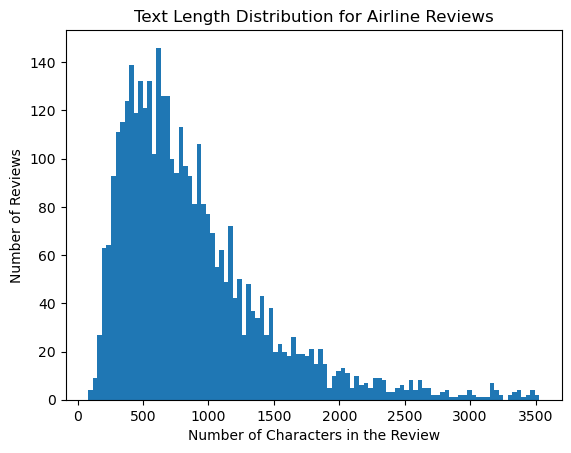

In [11]:
#2.2.3: Text Length Distribution Histogram

#Finds the number of characters for each review and stores them in a variable
text_len_hist_data=review_df["ReviewBody"].str.len()

#Create the histogram with enough bins to show the distribution clearly
plt.hist(text_len_hist_data,bins=100)
plt.xlabel("Number of Characters in the Review")
plt.ylabel("Number of Reviews")
plt.title("Text Length Distribution for Airline Reviews")

#Save the Figure as a .png file
#plt.savefig("text_length_distribution_hist.png")
plt.show()

In [12]:
text_len_hist_data.max()

3529

In [13]:
#2.3 Initial Observations
#2.3.1 What Language is it in

#The reviews are mainly written in English.

#2.3.2 Do you see any HTML Tags?

#Looking at over 400 reviews, I have not encountered any HTML tags in the bodies of the reviews.

#2.3.3 Are there any obvious cleaning issues?

#There are some cleaning issues including the differentiating currency signs, but asides from that there weren't
# any obvious cleaning steps that could be applied to all of the reviews. The problem with this is that there is
# no uniform formatting within the reviews and it is written by different people from all over the world. This
# means that there are going to be some symbollic differences (i.e. $ and £). With that many reviews, people will
#also write in a style that is unique to them. This means that there will varying kinds of reviews.

#2.3.4 What patterns do you notice?

#I noticed that when people are writing their reviews, they will include the patter of their trip by listing their stops
# followed by a "-".

#Special Characters

#Case id 3655 â€˜
#Case id 3654 â€œkeep tryingâ€ , â€“
#Case id 3634 contains $
#Case id 3613  Â£20
#Case id 3607 Â£1000
#Case id 3579 â€“
#Case id 3537 Â£240
#Case id 3513  anyoneâ€™s legs
#Case id 3500,3499 Â£120
#Case id 3411 Â£284

#Fixed this by using the encoding argument in the read CSV
#cp1252 'iso-8859-1'

In [14]:
#Show an example of text with the special characters (This was fixed earlier when the encoding argument was added to the read_csv function)
review_df['ReviewBody'][3579]

'Club World–LGW to TPA week later MIA to LHR. Gatwick check in quick and easy BA member came over and pointed us through Fast Track and gave lounge instructions. Lounge food offering very disappointing compared to LHR made do with Marmite on toast and lots of Champagne! In celebratory mood as going for a 30th cabin crew outbound fantastic the drinks kept flowing and never a rolled eye or any surly attitude from the crew. Managed 4/5 hours afternoon nap. Upgraded WTP home bound to CW through AVIOS 24hrs before and even bagged upper deck. An amazing night flight left on time. Have always found UD crew fantastic two pre departure drinks and mixed fleet seemed genuinely flying to serve. Only downside was pretty terrible dinner - starter and salad dreadful steak main not much better. Requested tray be taken away and skip dessert. Reclined and slept - and got woken 6 hours later for a bacon roll. Landed at LHR on time through security four bags collected and out of airport in 25 minutes. Clu

In [15]:
#STEP 3: Text Cleaning Processes

#Step 3.1.1 and 3.1.2
#Function that removes any HTML Tags that may exist in the reviews
def clean_text(text):
    return BeautifulSoup(text, "html.parser").get_text()

#Step 3.1.3
#Function that removes special characters from the text
def remove_spec_char(text):
    return re.sub(r'[^a-zA-Z0-9. !?]', ' ', text)

def remove_spec_char_textblob(text):
    return re.sub(r'[^a-zA-Z0-9. ]', ' ', text)

#Function to correct spelling for TextBlob
def correct_spelling_textblob(text):
    raw=TextBlob(text)
    return raw.correct()

#Step 3.1.4
#Function that expands contractions so we can properly vectorize
def expand_contractions_text(text):
    return contractions.fix(text)


#Step 3.1.6
#Text to remove any extra spaces in between and at the beginning of the text
def remove_extra_spaces(text):
    outer_space_clean=text.strip()
    final_clean= " ".join(text.split())
    return final_clean



In [16]:
#Takes the functions and creates a new column in the dataframe stores the cleaned text
review_df['clean_review'] = review_df['ReviewBody'].apply(clean_text)
review_df['clean_review']= review_df['clean_review'].apply(expand_contractions_text)
review_df['clean_review']= review_df['clean_review'].apply(remove_spec_char)
review_df['clean_review']= review_df['clean_review'].apply(remove_extra_spaces)

#Step 3.1.5
#Make the text lowercase for analysis
review_df['clean_review']= review_df['clean_review'].str.lower()

C:\Users\ysass\AppData\Local\Temp\ipykernel_11176\331695418.py:6: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [17]:
#3.2 Spot Check Validation
#Create a random list for the spot check
rand_spot_check=random.sample(range(1, num_rows), 4)
print(rand_spot_check)
#Run a loop that will print the original review along with the cleaned review
for i in range(0, len(rand_spot_check) - 1):
    print(f"Original Review: {review_df['ReviewBody'][rand_spot_check[i]]}")
    print(f"Cleaned Review: {review_df['clean_review'][rand_spot_check[i]]}")

[1116, 1235, 2776, 233]
Original Review: London to Dublin. This was an early morning departure from Heathrow on a full flight. BA managed everything in a very professional manner. The bag-drop was efficient and the boarding process was conducted according to the rules. The cabin crew were immaculate in appearance and conducted the safety demonstration along with a video. During this short and very busy flight the crew were able to sell drinks and snacks and left a superb impression. I had a not so good experience with this airline earlier in the year and am glad to see that this time they were superb.
Cleaned Review: london to dublin. this was an early morning departure from heathrow on a full flight. ba managed everything in a very professional manner. the bag drop was efficient and the boarding process was conducted according to the rules. the cabin crew were immaculate in appearance and conducted the safety demonstration along with a video. during this short and very busy flight the

In [18]:
#What was fixed

In [19]:
#Step 3.3 Remove Edge Cases

#Check if there are any empty strings after cleaning
print(review_df['clean_review'].isna().sum())

#Create a column that shows the word count for each review
review_df['wordcount']=review_df['clean_review'].str.split().str.len()
# In this case the minimum word count for a review is 8

0


In [20]:
#Import the stopwords in sklearn
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Convert to sorted list for better readability
stopwords_list = sorted(list(ENGLISH_STOP_WORDS))

# Print the number of stopwords and the first 20 stopwords as a sample
print("Total Stopwords in Sklearn:", len(stopwords_list))
print("Sample Stopwords:", stopwords_list[:20])

Total Stopwords in Sklearn: 318
Sample Stopwords: ['a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amoungst']


In [21]:
#Download the NLTK stopworks
nltk.download('stopwords') #need to download this pre-trained data for using with word tokenizer

#Store the NLTK stop words in a list in English
stop_words_nltk = list(stopwords.words('english')) #define English as the stop words

# Print the number of stopwords and the first 20 stopwords as a sample
print("Total Stopwords in NLTK:", len(stop_words_nltk))
print("Sample Stopwords:", stop_words_nltk[:20])

Total Stopwords in NLTK: 198
Sample Stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ysass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
#Text Pre-Processing
#Convert the reviews into a matrix that shows the word counts for each word
vectorizer = CountVectorizer(stop_words='english', max_features=5000)  # remove stop words, Limit features to 5000 words
#Fit the vectorizer to the cleaned reviews
X = vectorizer.fit_transform(review_df['clean_review'])

In [23]:
# To read it, we need to transform the Matrix to an array, another mathematical representation

# Convert to an array for readability
X_array = X.toarray()

# Get feature names ( / terms)
feature_names = vectorizer.get_feature_names_out()

# Print vocabulary
print("Vocabulary / Terms (Features):")
print(feature_names)

# Print the vectorized form of the first sentence
print("\nFirst Sentence Vector: ", review_df['clean_review'][0])
print(X_array[0])  # First sentence in vector form

# Convert to a dictionary for better readability
vector_dict = dict(zip(feature_names, X_array[0]))
print("\nWord Frequency in First Sentence:")
print(vector_dict)

Vocabulary / Terms (Features):
['00' '000' '00am' ... 'zoo' 'zrh' 'zurich']

First Sentence Vector:  4 hours before takeoff we received a mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. so did the capacity of the heathrow airport really hit british airways by surprise 4h before departure? anyhow we took the one hour delay so what but then we have been forced to check in our hand luggage. i travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. overall 2h later at home than planed with really no reason just due to incompetent people. service level far worse then ryanair and triple the price. really never again. thanks for nothing.
[0 0 0 ... 0 0 0]

Word Frequency in First Sentence:
{'00': 0, '000': 0, '00am': 0, '01': 0, '03': 0, '05': 0, '06': 0, '07': 0, '08': 0, '09': 0, '10': 0, '100': 0, '1000': 0, '10a': 0, '10am': 0, '10pm': 0, '10th': 0, '

In [24]:
print(review_df['clean_review'][1])
print(X_array[0])

i recently had a delay on british airways from bru to lhr that was due to staff shortages. they announced that there was a 2 hour holding delay but they would board us immediately in hopes of clearing the gate and leaving early. we had to wait the full 2 hours inside the airplane. the plane was old dirty had no power at the seats. the staff provided a small bag of pretzels and 250ml of water to the passengers for 2 hour delay and 2 hour flight. there were no options to purchase food or drink. there were no entertainment options available. i am a oneworld emerald elite member but they do not upgrade members based on status. first class lounges at heathrow are overcrowded understaffed and poorly equipped. the help desk is completely unhelpful when an error arises with delays and cancellations even when having the top status. the avios points system has been devalued to near worthlessness and requires fees to book reward that nearly equal the price of the revenue ticket. british has lost 

In [25]:
#Going through each clean review and removing the clean words one by one and put together the completely clean review
for review in range(0, len(review_df)):
    a = review_df.clean_review[review].split()
    sentence=[ x for x in a  if x not in stop_words_nltk]
    review_df['clean_review'][review]=" ".join(sentence)

C:\Users\ysass\AppData\Local\Temp\ipykernel_11176\1665748363.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['clean_review'][review]=" ".join(sentence)
C:\Users\ysass\AppData\Local\Temp\ipykernel_11176\1665748363.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['clean_review'][review]=" ".join(sentence)
C:\Users\ysass\AppData\Local\Temp\ipykernel_11176\1665748363.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

In [26]:
review_df['clean_review']

Id
0       4 hours takeoff received mail stating cryptic ...
1       recently delay british airways bru lhr due sta...
2       boarded time took ages get runway due congesti...
3       5 days flight advised ba cancelled asked us re...
4       traveled lisbon dream vacation cruise portugal...
                              ...                        
3696    bmi regional operated flight rj145 manchester ...
3697    lhr ham. purser addresses club passengers name...
3698    son worked british airways urged fly british a...
3699    london city new york jfk via shannon a318 real...
3700    sin lhr ba12 b747 436 first class. old aircraf...
Name: clean_review, Length: 3701, dtype: object

In [27]:
#STEP 4: Tokenize, Feature Engineer, and Vectorize

#4.1 VADER Pipeline

#1. Load the text into the file
#2. Clean the text (i.e. remove certain special characters and grammatical characters)
#3. Preprocessing: Use certain methods such as tokenization and vectorization with CountVectorizer
#4. Apply the SentimentIntensityAnalyzer to the text to get the compound score.


#4.1.1 How does VADER tokenize?

#VADER tokenizes by taking the raw text it is presented and splits it into individual words, punctuation, and any other groupings of characters 
#that it can find in the text. It can either use nltk.word_tokenize or Count_Vectorizer to tokenize the words.

#4.1.2 What features does VADER use? 

#VADER uses a lexicon (seen in a block later in the code) that has a rating value between -4 to 4 for many possible words that might be encountered
#in a text. Another feature that VADER utilizes is the capitalization of letters. Words that are in all capital letters may have a higher score
#than a word with all lower case letters. Certain punctuation is another feature that can affect the overall score of the text. An example is that exclamation point
#can affect the score more than a period. It can also use emojis. The specific emoji can indicate positive or negative impact on the message and change the score. 

#4.1.3 What preprocessing does VADER expect?

#VADER requires very minimal preprocessing because certain elements that would be cleaned has an affect on the way VADER processes the text. An example
#of this includes capitalization, emojis, and punctuation. It is important to keep certain elements in the text for VADER, but other elements including certain special characters
#should be removed as some of them do not have an affect. VADER also requires text cleaning, vectorization, and tokenization. 

#4.2 Textblob Pipeline

#1. Import and Load text
#2. Text cleaning (removal of HTML tags, expanding contraction, removing special characters, removing extra whitespace)
#3. Pre-Processing (lowercasing)
#4. Apply TextBlob functions to tokenize (words or sentences), and then apply sentiment analysis.

#4.2.1 How does Textblob tokenize?

#Textblob tokenizes by using two very specific functions to break down the text into smaller units. They can either use .words or .sentences methods within the Textblob
#library. These functions use the punctuation from the sentences or the whitespace depending on how deep they want to tokenize.

#4.2.2 What features does Textblob use? 

#4.2.3 What preprocessing does Textblob expect?



# 4.3 Transformer Pipeline


#4.3.1 How does distilbert-base-uncased-emotion tokenize? 


#4.3.2 What features does distilbert use?


#4.3.3 What preprocessing does distilbert expect?


#4.4 Key Differences

# 4.4.1 Document any differences in Tokenization approach 

#First they conduct the same processes when it comes to tokenization from both options. Both VADER and Textblob can tokenize by identifying individual elements
#to help determine sentiment. However, a major notable difference is that the VADER and TextBlob libraries have their own specific functions that handle tokenization.
#Another fundamental difference is that VADER is able to take other forms of text including emojis and punctuation into sentiment analysis, while Textblob is specifically
#for text only.

#4.4.2 Document any differences in Feature engineering 

#4.4.3 Document any differences in Vectorization 

#When it is being vectorized, VADER is able to handle the smaller text and unknown words/slang because it was initially meant to be used for social media analysis. When
#looking at Texblob, it can be used on text mainly; however, when it sees words that it doesn't know in the tokenization it will be skipped over during the vectorization process. 

#4.4.4 Document any differences in Preprocessing requirements

#Since VADER relies on capitalization and punctuation to determine the sentiment, we do not need to remove punctuation or lowercase text
# for VADER. For Textblob, it is important that all of the text is lowercased. 



In [28]:
#STEP 5: Apply Pretrained Models

#5.1 VADER Implelmentation
#Start with the text cleaning steps from Step 2

#Removing HTML Tags
review_df['clean_review_vader'] = review_df['ReviewBody'].apply(clean_text)
#Need to Expand Contractions
review_df['clean_review_vader']= review_df['clean_review_vader'].apply(expand_contractions_text)
#Need to remove extra special characters while leaving the punctaution there
review_df['clean_review_vader']= review_df['clean_review_vader'].apply(remove_spec_char)
#Removing Extra Spaces
review_df['clean_review_vader']= review_df['clean_review_vader'].apply(remove_extra_spaces)

C:\Users\ysass\AppData\Local\Temp\ipykernel_11176\331695418.py:6: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [29]:
review_df['clean_review_vader']

Id
0       4 Hours before takeoff we received a Mail stat...
1       I recently had a delay on British Airways from...
2       Boarded on time but it took ages to get to the...
3       5 days before the flight we were advised by BA...
4       We traveled to Lisbon for our dream vacation a...
                              ...                        
3696    This was a bmi Regional operated flight on a R...
3697    LHR to HAM. Purser addresses all club passenge...
3698    My son who had worked for British Airways urge...
3699    London City New York JFK via Shannon on A318 b...
3700    SIN LHR BA12 B747 436 First Class. Old aircraf...
Name: clean_review_vader, Length: 3701, dtype: object

In [30]:
#Tokenize and Vectorize the text

#Convert the reviews into a matrix that shows the word counts for each word
vectorizer_vader = CountVectorizer(stop_words='english', max_features=5000)  # remove stop words, Limit features to 5000 words
#Fit the vectorizer to the cleaned reviews
X_vader = vectorizer_vader.fit_transform(review_df['clean_review_vader'])

In [31]:
# Convert to an array for readability
X_array_vader = X_vader.toarray()

# Get feature names ( / terms)
feature_names_vader = vectorizer_vader.get_feature_names_out()

# Print vocabulary
print("Vocabulary / Terms (Features):")
print(feature_names_vader)

# Print the vectorized form of the first sentence
print("\nFirst Sentence Vector: ", review_df['clean_review_vader'][0])
print(X_array_vader[0])  # First sentence in vector form

# Convert to a dictionary for better readability
vector_dict_vader = dict(zip(feature_names_vader, X_array_vader[0]))
print("\nWord Frequency in First Sentence:")
print(vector_dict_vader)

Vocabulary / Terms (Features):
['00' '000' '00am' ... 'zoo' 'zrh' 'zurich']

First Sentence Vector:  4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise 4h before departure? Anyhow we took the one hour delay so what but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed with really no reason just due to incompetent people. Service level far worse then Ryanair and triple the price. Really never again. Thanks for nothing.
[0 0 0 ... 0 0 0]

Word Frequency in First Sentence:
{'00': 0, '000': 0, '00am': 0, '01': 0, '03': 0, '05': 0, '06': 0, '07': 0, '08': 0, '09': 0, '10': 0, '100': 0, '1000': 0, '10a': 0, '10am': 0, '10pm': 0, '10th': 0, '

In [32]:
review_df['clean_review_vader']

Id
0       4 Hours before takeoff we received a Mail stat...
1       I recently had a delay on British Airways from...
2       Boarded on time but it took ages to get to the...
3       5 days before the flight we were advised by BA...
4       We traveled to Lisbon for our dream vacation a...
                              ...                        
3696    This was a bmi Regional operated flight on a R...
3697    LHR to HAM. Purser addresses all club passenge...
3698    My son who had worked for British Airways urge...
3699    London City New York JFK via Shannon on A318 b...
3700    SIN LHR BA12 B747 436 First Class. Old aircraf...
Name: clean_review_vader, Length: 3701, dtype: object

In [33]:
#Download the lexicon that vader uses to score its text
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ysass\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [34]:
#Initialize the Sentiment Intensity Analyzer so we can get sentiment ratings for each review
sid = SentimentIntensityAnalyzer()

In [35]:
#Create a section of the dataframe that shows the reviews with the best (10.0) or worst (1.0) ratings and reset the index so we can index off of that list
reviews_best_worst = review_df[(review_df["OverallRating"]==10.0) | (review_df["OverallRating"]==1.0)].reset_index()

In [36]:
reviews_best_worst

,Id,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,...,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount,clean_review_vader
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,...,1.0,1.0,no,NaN,NaN,NaN,NaN,4 hours takeoff received mail stating cryptic ...,123,4 Hours before takeoff we received a Mail stat...
1,3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,...,1.0,1.0,no,NaN,NaN,NaN,NaN,5 days flight advised ba cancelled asked us re...,256,5 days before the flight we were advised by BA...
2,4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,...,1.0,1.0,no,NaN,1.0,1.0,1.0,traveled lisbon dream vacation cruise portugal...,175,We traveled to Lisbon for our dream vacation a...
3,5,1.0,"""I can’t imagine a worst airline""",A Narden,12th November 2023,True,Booked a flight from Bucharest to Manchester w...,Solo Leisure,Economy Class,Bucharest to Manchester via London,...,1.0,1.0,no,A320,1.0,1.0,NaN,booked flight bucharest manchester 2h 45 layov...,205,Booked a flight from Bucharest to Manchester w...
4,11,1.0,“BA clearly does not care”,J Furlong,31st October 2023,True,1. Ground crew in Heathrow left 60 passengers ...,Couple Leisure,Economy Class,Anchorage to Heathrow via Barcelona,...,1.0,1.0,no,NaN,3.0,3.0,3.0,1. ground crew heathrow left 60 passengers lug...,232,1. Ground crew in Heathrow left 60 passengers ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,3681,10.0,British Airways customer review,C Denson,5th May 2014,False,Chicago O'Hare to London Heathrow on 2 May. ch...,NaN,Economy Class,NaN,...,NaN,5.0,yes,NaN,5.0,4.0,NaN,chicago hare london heathrow 2 may. check fast...,37,Chicago O Hare to London Heathrow on 2 May. ch...
1191,3682,10.0,British Airways customer review,A Hickling,4th May 2014,False,Travelled to HKG on board the new A380. Boardi...,NaN,First Class,NaN,...,NaN,5.0,yes,NaN,5.0,5.0,NaN,travelled hkg board new a380. boarding efficie...,187,Travelled to HKG on board the new A380. Boardi...
1192,3683,1.0,British Airways customer review,Iain Henderson,3rd May 2014,False,BA 059 London to Cape Town April 29 2014 econo...,NaN,Economy Class,NaN,...,NaN,1.0,no,NaN,1.0,1.0,NaN,ba 059 london cape town april 29 2014 economy....,143,BA 059 London to Cape Town April 29 2014 econo...
1193,3693,10.0,British Airways customer review,J Tinning,29th August 2012,False,Flew LHR - VIE return operated by bmi but BA a...,NaN,Economy Class,NaN,...,NaN,4.0,yes,NaN,5.0,NaN,NaN,flew lhr vie return operated bmi ba aircraft. ...,81,Flew LHR VIE return operated by bmi but BA air...


In [37]:
review_df.sample(10)

,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,...,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount,clean_review_vader
Id,,,,,,,,,,,,,,,,,,,,,
341,1.0,"""become an absolute nightmare""",Mark Robinson,13th July 2022,True,Over 1 week ago I cancelled 2 Club Europe flig...,NaN,Business Class,London to Malaga,Jul-22,...,NaN,1.0,no,NaN,NaN,NaN,NaN,1 week ago cancelled 2 club europe flights due...,118,Over 1 week ago I cancelled 2 Club Europe flig...
16,8.0,"""an exceptional crew member""",Philip Thompson,22nd October 2023,False,Flew back from Malta after scattering our son'...,Couple Leisure,Economy Class,Malta to London Gatwick,Oct-23,...,4.0,4.0,yes,A320,3.0,NaN,NaN,flew back malta scattering son ashes favourite...,109,Flew back from Malta after scattering our son ...
3467,10.0,British Airways customer review,Shilen Bhimjiyani,28th August 2014,False,LHR-LAX and ORD-LHR. Great crew on both flight...,NaN,Economy Class,NaN,NaN,...,NaN,5.0,yes,NaN,5.0,5.0,NaN,lhr lax ord lhr. great crew flights. new aircr...,55,LHR LAX and ORD LHR. Great crew on both flight...
3504,10.0,British Airways customer review,Tony Hall,2nd August 2014,False,AMS-LCY economy. Embraer aircraft only half-fu...,NaN,Business Class,NaN,NaN,...,NaN,5.0,yes,NaN,4.0,2.0,NaN,ams lcy economy. embraer aircraft half full ti...,37,AMS LCY economy. Embraer aircraft only half fu...
1740,1.0,"""turning BA into a low-cost carrier""",R Thomas,7th April 2017,False,I am just sad to have to write this review. I ...,Business,Premium Economy,Cape Town to Berlin via London,Jan-17,...,3.0,1.0,no,Boeing 747,1.0,2.0,NaN,sad write review. changed lufthansa british ai...,269,I am just sad to have to write this review. I ...
2964,8.0,British Airways customer review,L Laidlaw,27th May 2015,False,Business Class Tampa - Gatwick. Fantastic serv...,NaN,Business Class,NaN,NaN,...,NaN,4.0,yes,NaN,5.0,4.0,NaN,business class tampa gatwick. fantastic servic...,41,Business Class Tampa Gatwick. Fantastic servic...
3377,9.0,British Airways customer review,C Cutts,12th October 2014,False,LHR-MXP-LHR. Check in/bag drop at T5 once agai...,NaN,Economy Class,NaN,NaN,...,NaN,3.0,yes,NaN,4.0,1.0,NaN,lhr mxp lhr. check bag drop t5 slow appears st...,131,LHR MXP LHR. Check in bag drop at T5 once agai...
86,1.0,"""bumped off due to overselling""",Alison Spencer,31st July 2023,True,Couldn’t book in online. Arrived at check in t...,Couple Leisure,Economy Class,Gatwick to Montpelier,Jul-23,...,1.0,1.0,no,NaN,1.0,NaN,NaN,could book online. arrived check find bumped d...,69,Could not book in online. Arrived at check in ...
3026,7.0,British Airways customer review,C Hadjinicolaou,23rd April 2015,False,BA662 31st March. BA662 14th April. BA makes u...,NaN,Economy Class,NaN,NaN,...,NaN,3.0,yes,NaN,1.0,3.0,NaN,ba662 31st march. ba662 14th april. ba makes u...,46,BA662 31st March. BA662 14th April. BA makes u...


In [38]:
#Shows the 1st review along with the polarity score using the VADER method.
print(reviews_best_worst.loc[1.0, 'ReviewBody'])
print()
sid.polarity_scores(reviews_best_worst.loc[1.0, 'ReviewBody'])

5 days before the flight, we were advised by BA that it had been cancelled and asked us to rebook. There were flights 1 hour before and 1 hour after our original flight but they made us take one 3 hours earlier. Our original ticket (and the return flight a week later) included a checked bag. When we arrive at Heathrow to check in we are told our ticket doesn't included a bag and we will have to pay 75 pounds each to take them. We explained that the original ticket had the bags and when they checked the system they confirmed that it did- but not this one! They would make no effort to sort it out and just told us to pay up or they would remove us from the flight. So we had no choice but to pay up, thinking it should be pretty easy to get a refund. 15 months and 10 emails later we have still not seen a penny. Every time I ask where my refund is and state how long we have been waiting I get an inane email saying some departments take longer than others to respond!  Absolutely hopeless airl

{'neg': 0.102, 'neu': 0.833, 'pos': 0.066, 'compound': -0.8327}

In [39]:
print(reviews_best_worst.loc[10.0, 'ReviewBody'])
print()
sid.polarity_scores(reviews_best_worst.loc[10.0, 'ReviewBody'])

They downgraded me from business to premium economy. They took three months to get back to me and offered me 200 pounds or 400 AUD. The difference between business class and premium economy (which I never fly) is $3000 AUD and the difference between economy and business is $6500 AUD. They owe me at least 1500 pounds and to be very fair 3250 pounds. The downgrade was insulting and incredibly painful as I had a recent cancer operation and have a back injury which I have pointed out to them - I need to lie down. The wait for them to get around to me has been numbing. The insult of their offer has been the slap in the face to continue my degradation. The people I have dealt with at the airport have been down to earth, honest hard working people. The actual staff on the plane were warm and friendly - and helpful. The systems under which BA operates are some sort of medieval torture.



{'neg': 0.15, 'neu': 0.767, 'pos': 0.083, 'compound': -0.9273}

In [40]:
#Shows the worst reviews
reviews_best_worst[reviews_best_worst["OverallRating"]==1.0]

,Id,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,...,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount,clean_review_vader
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,...,1.0,1.0,no,NaN,NaN,NaN,NaN,4 hours takeoff received mail stating cryptic ...,123,4 Hours before takeoff we received a Mail stat...
1,3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,...,1.0,1.0,no,NaN,NaN,NaN,NaN,5 days flight advised ba cancelled asked us re...,256,5 days before the flight we were advised by BA...
2,4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,...,1.0,1.0,no,NaN,1.0,1.0,1.0,traveled lisbon dream vacation cruise portugal...,175,We traveled to Lisbon for our dream vacation a...
3,5,1.0,"""I can’t imagine a worst airline""",A Narden,12th November 2023,True,Booked a flight from Bucharest to Manchester w...,Solo Leisure,Economy Class,Bucharest to Manchester via London,...,1.0,1.0,no,A320,1.0,1.0,NaN,booked flight bucharest manchester 2h 45 layov...,205,Booked a flight from Bucharest to Manchester w...
4,11,1.0,“BA clearly does not care”,J Furlong,31st October 2023,True,1. Ground crew in Heathrow left 60 passengers ...,Couple Leisure,Economy Class,Anchorage to Heathrow via Barcelona,...,1.0,1.0,no,NaN,3.0,3.0,3.0,1. ground crew heathrow left 60 passengers lug...,232,1. Ground crew in Heathrow left 60 passengers ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1184,3654,1.0,British Airways customer review,C Tyler,18th May 2014,False,When we booked our holiday to Barbados I was r...,NaN,Economy Class,NaN,...,NaN,2.0,no,NaN,1.0,1.0,NaN,booked holiday barbados really pleased see fly...,479,When we booked our holiday to Barbados I was r...
1185,3662,1.0,British Airways customer review,Kathleen Osborne,12th May 2014,False,I should be in a nice hotel in Romania instead...,NaN,Economy Class,NaN,...,NaN,1.0,no,NaN,3.0,1.0,NaN,nice hotel romania instead 9 hours arrived hea...,280,I should be in a nice hotel in Romania instead...
1189,3676,1.0,British Airways customer review,P Harris,7th May 2014,False,Lanzarote to Gatwick on 13th April. Flight its...,NaN,Economy Class,NaN,...,NaN,2.0,no,NaN,3.0,1.0,NaN,lanzarote gatwick 13th april. flight okay arri...,132,Lanzarote to Gatwick on 13th April. Flight its...
1192,3683,1.0,British Airways customer review,Iain Henderson,3rd May 2014,False,BA 059 London to Cape Town April 29 2014 econo...,NaN,Economy Class,NaN,...,NaN,1.0,no,NaN,1.0,1.0,NaN,ba 059 london cape town april 29 2014 economy....,143,BA 059 London to Cape Town April 29 2014 econo...


In [41]:
print(reviews_best_worst.loc[1194, 'clean_review'])
print()
sid.polarity_scores(reviews_best_worst.loc[1194, 'clean_review'])

bmi regional operated flight rj145 manchester heathrow ba flight number report here. boarding cabin crew member look check boarding passes welcome us. check seatbelts etc. prior takeoff. service started soon takeoff since short flight consisted trolley drinks snacks usual ba domestic services. 5 men front returning weekend break given 2 gin tonics cabin steward friendly them. got stared stared back took forgotten say may offer something bar something similar. asked orange juice exactly thrust onto tray. asked ice got one lump splashed juice reluctantly. none rest us offered drink expect short flight. goodbye departure grimace surprise me. sad see bmi staff lost sense pride jobs.



{'neg': 0.092, 'neu': 0.804, 'pos': 0.104, 'compound': 0.3182}

In [42]:
sns.set(rc={'figure.figsize':(30,1)})

def visualise_sentiments(data):
  sns.heatmap(pd.DataFrame(data).set_index("Sentence").T,center=0, annot=True, cmap = "PiYG")

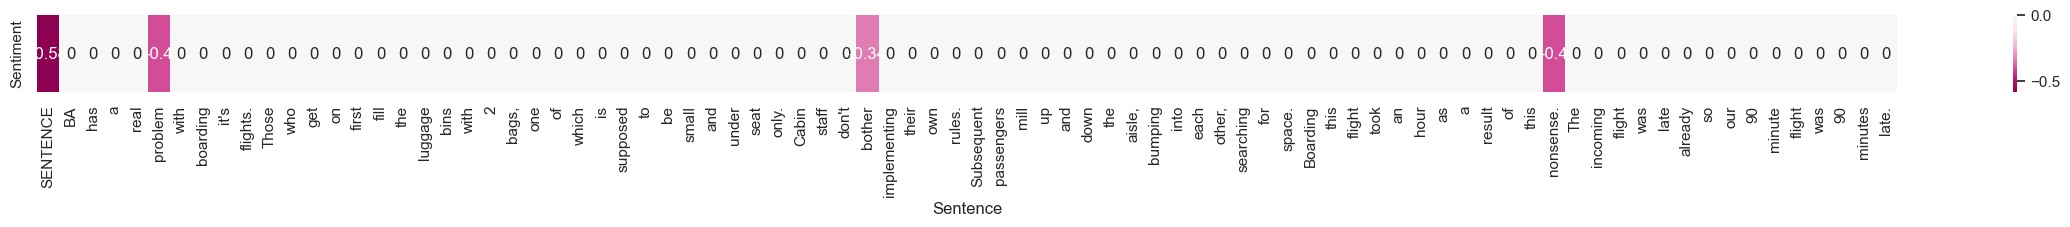

In [43]:
visualise_sentiments({
    "Sentence":["SENTENCE"] + reviews_best_worst.loc[12, 'ReviewBody'].split(),
    "Sentiment":[sid.polarity_scores(reviews_best_worst.loc[12, 'ReviewBody'])["compound"]]
    + [sid.polarity_scores(word)["compound"] for word in reviews_best_worst.loc[12, 'ReviewBody'].split()]
})

In [44]:
# create a new DataFrame column for compound
review_df['vader_compound_score'] = review_df['ReviewBody'].apply(sid.polarity_scores)
review_df.head(2)

,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,...,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount,clean_review_vader,vader_compound_score
Id,,,,,,,,,,,,,,,,,,,,,
0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,Nov-23,...,1.0,no,NaN,NaN,NaN,NaN,4 hours takeoff received mail stating cryptic ...,123,4 Hours before takeoff we received a Mail stat...,"{'neg': 0.185, 'neu': 0.744, 'pos': 0.071, 'co..."
1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,Nov-23,...,2.0,no,A320,1.0,2.0,2.0,recently delay british airways bru lhr due sta...,206,I recently had a delay on British Airways from...,"{'neg': 0.136, 'neu': 0.783, 'pos': 0.081, 'co..."


In [45]:
#5.2 Implementing TextBlob

#Text Cleaning
#Removing HTML Tags
review_df['clean_review_tb'] = review_df['ReviewBody'].apply(clean_text)
#Need to Expand Contractions
review_df['clean_review_tb']= review_df['clean_review_tb'].apply(expand_contractions_text)
#Need to remove extra special characters while leaving the punctaution there
review_df['clean_review_tb']= review_df['clean_review_tb'].apply(remove_spec_char_textblob)
#Removing Extra Spaces
review_df['clean_review_tb']= review_df['clean_review_tb'].apply(remove_extra_spaces)
#Correct Spelling Mistakes
review_df['clean_review_tb']= review_df['clean_review_tb'].apply(correct_spelling_textblob)
#Make the text lowercase for analysis
review_df['clean_review_tb']= review_df['clean_review_tb'].str.lower()



# define a function that accepts text and returns the polarity
def detect_sentiment(text):

    #Converts the text into textblob object and then retuns
    #the subjectivity.
    blob = TextBlob(text)

    # return the subjectivity
    return blob.sentiment

In [46]:
review_df["TextBlob_Analysis (Polarity, Subjectivity)"] = review_df.ReviewBody.apply(detect_sentiment)

In [47]:
review_df

,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,...,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount,clean_review_vader,vader_compound_score,"TextBlob_Analysis (Polarity, Subjectivity)"
Id,,,,,,,,,,,,,,,,,,,,,
0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,Nov-23,...,no,NaN,NaN,NaN,NaN,4 hours takeoff received mail stating cryptic ...,123,4 Hours before takeoff we received a Mail stat...,"{'neg': 0.185, 'neu': 0.744, 'pos': 0.071, 'co...","(-0.045588235294117645, 0.3392156862745098)"
1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,Nov-23,...,no,A320,1.0,2.0,2.0,recently delay british airways bru lhr due sta...,206,I recently had a delay on British Airways from...,"{'neg': 0.136, 'neu': 0.783, 'pos': 0.081, 'co...","(0.006944444444444438, 0.36712962962962964)"
2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,Nov-23,...,yes,A320,4.0,NaN,NaN,boarded time took ages get runway due congesti...,54,Boarded on time but it took ages to get to the...,"{'neg': 0.0, 'neu': 0.931, 'pos': 0.069, 'comp...","(0.12803030303030302, 0.43409090909090914)"
3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,Dec-22,...,no,NaN,NaN,NaN,NaN,5 days flight advised ba cancelled asked us re...,256,5 days before the flight we were advised by BA...,"{'neg': 0.102, 'neu': 0.833, 'pos': 0.066, 'co...","(0.11972222222222226, 0.5853968253968254)"
4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,Nov-23,...,no,NaN,1.0,1.0,1.0,traveled lisbon dream vacation cruise portugal...,175,We traveled to Lisbon for our dream vacation a...,"{'neg': 0.013, 'neu': 0.922, 'pos': 0.065, 'co...","(-0.08411458333333333, 0.3194444444444445)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,1.0,British Airways customer review,J Robertson,29th August 2012,False,This was a bmi Regional operated flight on a R...,NaN,Economy Class,NaN,NaN,...,no,NaN,2.0,NaN,NaN,bmi regional operated flight rj145 manchester ...,226,This was a bmi Regional operated flight on a R...,"{'neg': 0.094, 'neu': 0.848, 'pos': 0.058, 'co...","(0.09196428571428572, 0.41000000000000003)"
3697,9.0,British Airways customer review,Nick Berry,28th August 2012,False,LHR to HAM. Purser addresses all club passenge...,NaN,Business Class,NaN,NaN,...,yes,NaN,4.0,NaN,NaN,lhr ham. purser addresses club passengers name...,25,LHR to HAM. Purser addresses all club passenge...,"{'neg': 0.0, 'neu': 0.712, 'pos': 0.288, 'comp...","(0.1732142857142857, 0.42857142857142855)"
3698,5.0,British Airways customer review,Avril Barclay,12th October 2011,False,My son who had worked for British Airways urge...,NaN,Economy Class,NaN,NaN,...,yes,NaN,NaN,NaN,NaN,son worked british airways urged fly british a...,231,My son who had worked for British Airways urge...,"{'neg': 0.056, 'neu': 0.875, 'pos': 0.069, 'co...","(0.14314814814814816, 0.2822222222222222)"


In [51]:
#5.3 Transformer 
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained("bhadresh-savani/distilbert-base-uncased-emotion")
model = AutoModelForSequenceClassification.from_pretrained("bhadresh-savani/distilbert-base-uncased-emotion")

from transformers import pipeline
classifier = pipeline("text-classification",model='bhadresh-savani/distilbert-base-uncased-emotion', return_all_scores=True)
prediction = classifier(review_df['ReviewBody'], )
print(prediction)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).